Cricket Data Analysis Using Machine Learning
CS-471 – Machine Learning
**Semester Project**(CEP)

---

---

**BESE-29 C**

**Group Member:**

*   Faiza Malik
*  Khansa Farooq
*  Hamna Mushtaq

This project focuses on applying machine learning techniques to analyze
cricket match data and predict match outcomes / scores using the Cricsheet dataset.


In [ ]:
# Mount Google Drive
# =========================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import yaml
import pandas as pd

# =========================
# Set Paths
# =========================
base_path = "/content/drive/MyDrive/cricket_cep"
odi_folder = os.path.join(base_path, "odis")

In [ ]:
print("Files in base path:", os.listdir(base_path))
print("YAML files in ODI folder:", os.listdir(odi_folder))


Files in base path: ['odis']
YAML files in ODI folder: ['65248.yaml', '65276.yaml', '65262.yaml', '433590.yaml', '64850.yaml', '660825.yaml', '649095.yaml', '770127.yaml', '730289.yaml', '573015.yaml', '573026.yaml', '584547.yaml', '914215.yaml', '560926.yaml', '66293.yaml', '464529.yaml', '643665.yaml', '749775.yaml', '65277.yaml', '564781.yaml', '66196.yaml', '722339.yaml', '710291.yaml', '66297.yaml', '65237.yaml', '594914.yaml', '860271.yaml', '540168.yaml', '736511.yaml', '656435.yaml', '656447.yaml', '597929.yaml', '66378.yaml', '65260.yaml', '578625.yaml', '66364.yaml', '750675.yaml', '433603.yaml', '656427.yaml', '743945.yaml', '64939.yaml', '65238.yaml', '66210.yaml', '422629.yaml', '65249.yaml', '66374.yaml', '65646.yaml', '657645.yaml', '895811.yaml', '565813.yaml', '567368.yaml', '518967.yaml', '64855.yaml', '656407.yaml', '65239.yaml', '65637.yaml', '65235.yaml', '710297.yaml', '456663.yaml', '489213.yaml', '666039.yaml', '800475.yaml', '433604.yaml', '535796.yaml', '91421

In [ ]:
# =========================
# Read YAML files and extract data
# =========================
all_deliveries = []
match_info_list = []

yaml_files = [f for f in os.listdir(odi_folder) if f.endswith(".yaml")]
print("✅ Total YAML files:", len(yaml_files))

for idx, file in enumerate(yaml_files, 1):
    path = os.path.join(odi_folder, file)
    try:
        with open(path, "r", encoding="utf-8") as f:
            match = yaml.safe_load(f)
    except:
        continue

    if not match or "innings" not in match:
        continue

    # Match-level info
    info = match.get("info", {})
    outcome = info.get("outcome", {})
    match_id = file.replace(".yaml", "")

    teams = info.get("teams", [])
    toss = info.get("toss", {})
    toss_winner = toss.get("winner", "Unknown")
    toss_decision = toss.get("decision", "Unknown")
    winner = outcome.get("winner", "Unknown")
    city = info.get("city", "Unknown")
    venue = info.get("venue", "Unknown")
    overs = info.get("overs", 50)

    match_info_list.append({
        "match_id": match_id,
        "teams": teams,
        "city": city,
        "venue": venue,
        "toss_winner": toss_winner,
        "toss_decision": toss_decision,
        "winner": winner,
        "overs": overs
    })

    # Ball-by-ball info
    for inning in match["innings"]:
        for inning_name, inning_data in inning.items():
            batting_team = inning_data.get("team", "")
            bowling_team = [t for t in teams if t != batting_team][0]
            deliveries = inning_data.get("deliveries", [])

            for d in deliveries:
                ball_no = list(d.keys())[0]
                data = d[ball_no]
                runs_info = data.get("runs", {})

                all_deliveries.append({
                    "match_id": match_id,
                    "inning": inning_name,
                    "batting_team": batting_team,
                    "bowling_team": bowling_team,
                    "ball": ball_no,
                    "batsman": data.get("batsman") or data.get("batter"),
                    "bowler": data.get("bowler"),
                    "runs": runs_info.get("total", 0),
                    "extras": runs_info.get("extras", 0),
                    "winner": winner
                })

    if idx % 100 == 0:
        print(f"Processed {idx}/{len(yaml_files)} files")

✅ Total YAML files: 3000
Processed 100/3000 files
Processed 200/3000 files
Processed 300/3000 files
Processed 400/3000 files
Processed 500/3000 files
Processed 600/3000 files
Processed 700/3000 files
Processed 800/3000 files
Processed 900/3000 files
Processed 1000/3000 files
Processed 1100/3000 files
Processed 1200/3000 files
Processed 1300/3000 files
Processed 1400/3000 files
Processed 1500/3000 files
Processed 1600/3000 files
Processed 1700/3000 files
Processed 1800/3000 files
Processed 1900/3000 files
Processed 2000/3000 files
Processed 2100/3000 files
Processed 2200/3000 files
Processed 2300/3000 files
Processed 2400/3000 files
Processed 2500/3000 files
Processed 2600/3000 files
Processed 2700/3000 files
Processed 2800/3000 files
Processed 2900/3000 files
Processed 3000/3000 files


In [ ]:
# =========================
# Create DataFrames
# =========================
df_deliveries = pd.DataFrame(all_deliveries)
df_matches = pd.DataFrame(match_info_list)

# Merge match info with deliveries
df_full = df_deliveries.merge(df_matches, on="match_id", how="left")

# Save cleaned CSV
csv_path = "/content/odi_deliveries_full.csv"
df_full.to_csv(csv_path, index=False)
print("✅ Full ball-by-ball CSV saved!")
print("Total rows:", len(df_full))

✅ Full ball-by-ball CSV saved!
Total rows: 1588920


In [ ]:
import pandas as pd

# adjust filename if required
df = pd.read_csv('/content/odi_deliveries_full.csv')

print(df.shape)
df.head()

(1588920, 17)


,match_id,inning,batting_team,bowling_team,ball,batsman,bowler,runs,extras,winner_x,teams,city,venue,toss_winner,toss_decision,winner_y,overs
0,65248,1st innings,South Africa,New Zealand,0.1,GC Smith,SE Bond,0,0,New Zealand,"['South Africa', 'New Zealand']",Johannesburg,"New Wanderers Stadium, Johannesburg",South Africa,bat,New Zealand,50
1,65248,1st innings,South Africa,New Zealand,0.2,GC Smith,SE Bond,0,0,New Zealand,"['South Africa', 'New Zealand']",Johannesburg,"New Wanderers Stadium, Johannesburg",South Africa,bat,New Zealand,50
2,65248,1st innings,South Africa,New Zealand,0.3,GC Smith,SE Bond,1,1,New Zealand,"['South Africa', 'New Zealand']",Johannesburg,"New Wanderers Stadium, Johannesburg",South Africa,bat,New Zealand,50
3,65248,1st innings,South Africa,New Zealand,0.4,GC Smith,SE Bond,1,1,New Zealand,"['South Africa', 'New Zealand']",Johannesburg,"New Wanderers Stadium, Johannesburg",South Africa,bat,New Zealand,50
4,65248,1st innings,South Africa,New Zealand,0.5,GC Smith,SE Bond,0,0,New Zealand,"['South Africa', 'New Zealand']",Johannesburg,"New Wanderers Stadium, Johannesburg",South Africa,bat,New Zealand,50


In [ ]:
# =========================
# Data Preprocessing
# =========================
# Ensure correct dtypes
df_full['runs'] = df_full['runs'].astype(int)
df_full['extras'] = df_full['extras'].astype(int)

In [ ]:
# Remove invalid matches (must have 2 teams)
valid_matches = df_full.groupby('match_id')['batting_team'].nunique()
valid_matches = valid_matches[valid_matches == 2].index
df_full = df_full[df_full['match_id'].isin(valid_matches)]

In [ ]:
# Step 1: Convert any list-type cells to tuples (hashable, so drop_duplicates works)
df_full = df_full.applymap(lambda x: tuple(x) if isinstance(x, list) else x)

# Step 2: Remove duplicate rows
df_full.drop_duplicates(inplace=True)

/tmp/ipython-input-3043150333.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_full = df_full.applymap(lambda x: tuple(x) if isinstance(x, list) else x)


In [ ]:
# Step 3: Fill missing values in important categorical columns
df_full.fillna({
    'city': 'Unknown',
    'venue': 'Unknown',
    'toss_decision': 'Unknown',
    'winner': 'Unknown',

}, inplace=True)

In [ ]:

# Step 4: Handle numeric columns
# Fill missing numeric values with median (safer than mean if outliers exist)
numeric_cols = df_full.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    df_full[col].fillna(df_full[col].median(), inplace=True)

/tmp/ipython-input-1623249090.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_full[col].fillna(df_full[col].median(), inplace=True)


In [ ]:
print("Full preprocessing complete. Dataset shape:", df_full.shape)

Full preprocessing complete. Dataset shape: (1577189, 17)


In [ ]:
# Compute overs
df_full['overs'] = df_full.groupby(['match_id', 'inning']).cumcount() // 6 + 1

In [ ]:
print(df_full.columns)


Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'ball', 'batsman',
       'bowler', 'runs', 'extras', 'winner_x', 'teams', 'city', 'venue',
       'toss_winner', 'toss_decision', 'winner_y', 'overs'],
      dtype='object')


In [ ]:
# Keep the correct winner column
df_full['winner'] = df_full['winner_y']

# Drop duplicate/unused columns
df_full.drop(columns=['winner_x', 'winner_y'], inplace=True)


In [ ]:
innings_df = df_full.groupby([
    'match_id', 'inning', 'batting_team', 'bowling_team', 'winner',
    'venue', 'city', 'toss_winner', 'toss_decision'
]).agg(
    total_runs=('runs', 'sum'),
    total_extras=('extras', 'sum'),
    balls_played=('ball', 'count')
).reset_index()


In [ ]:
first_innings = innings_df[innings_df['inning'].str.contains('1st')][['match_id', 'total_runs']]
first_innings.rename(columns={'total_runs': 'first_innings_total'}, inplace=True)
innings_df = innings_df.merge(first_innings, on='match_id', how='left')

In [ ]:
# For 2nd innings
innings_df = innings_df[innings_df['inning'].str.contains('2nd')]

In [ ]:
# =========================
# Feature Engineering
# =========================

import numpy as np

# 1. Run rate per innings
innings_df['run_rate'] = innings_df['total_runs'] / (innings_df['balls_played'] / 6)


In [ ]:
# 2. Extras ratio (extras contribution to total runs)
innings_df['extras_ratio'] = innings_df['total_extras'] / innings_df['total_runs']

In [ ]:
# 3. Toss impact (did toss winner win the match?)
innings_df['toss_win_match'] = np.where(innings_df['toss_winner'] == innings_df['winner'], 1, 0)


In [ ]:
# 4. Batting first indicator
innings_df['bat_first'] = np.where(innings_df['inning'] == '1st innings', 1, 0)

In [ ]:
# 5. Encode categorical variables for analysis/modeling
categorical_cols = ['batting_team', 'bowling_team', 'venue', 'city', 'toss_winner', 'toss_decision']
innings_df_encoded = pd.get_dummies(innings_df, columns=categorical_cols, drop_first=True)

In [ ]:
innings_df['overs'] = innings_df['balls_played'] / 6

In [ ]:
# ✅ Runs left & Balls left
innings_df['runs_left'] = innings_df['first_innings_total'] - innings_df['total_runs']
innings_df['balls_left'] = 50*6 - innings_df['balls_played']
innings_df['required_rr'] = np.where(innings_df['balls_left']>0,
                                    innings_df['runs_left']/(innings_df['balls_left']/6), 0)

In [ ]:
innings_df['current_rr'] = innings_df['total_runs'] / innings_df['overs']
innings_df['extras_ratio'] = innings_df['total_extras'] / innings_df['total_runs'].replace(0, 1)
innings_df['toss_win_match'] = np.where(innings_df['toss_winner'] == innings_df['winner'], 1, 0)

In [ ]:
# View the final engineered dataframe
print(innings_df_encoded.head())

  match_id       inning     winner  total_runs  total_extras  balls_played  \
1  1000887  2nd innings  Australia         176            14           261   
3  1000889  2nd innings   Pakistan         221            13           293   
5  1000891  2nd innings  Australia         265             8           276   
7  1000893  2nd innings  Australia         267             9           267   
9  1000895  2nd innings  Australia         312            15           307   

   first_innings_total  run_rate  extras_ratio  toss_win_match  ...  \
1                  268  4.045977      0.079545               1  ...   
3                  220  4.525597      0.058824               0  ...   
5                  263  5.760870      0.030189               1  ...   
7                  353  6.000000      0.033708               1  ...   
9                  369  6.097720      0.048077               1  ...   

   toss_winner_Papua New Guinea  toss_winner_Scotland  \
1                         False                

In [ ]:
# Replace inf and -inf with NaN
innings_df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [ ]:
innings_df['extras_ratio'] = innings_df['extras_ratio'].fillna(0)


In [ ]:
innings_df['required_rr'] = innings_df['required_rr'].fillna(0)

In [ ]:
innings_df['run_rate'] = innings_df['run_rate'].fillna(0)
innings_df['current_rr'] = innings_df['current_rr'].fillna(0)


In [ ]:
numeric_cols = innings_df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    innings_df[col].fillna(innings_df[col].median(), inplace=True)


/tmp/ipython-input-3560873603.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  innings_df[col].fillna(innings_df[col].median(), inplace=True)


In [ ]:
print("Any NaNs left :", innings_df.isna().sum().sum())
print("Any infinities:", np.isinf(innings_df.select_dtypes(include=np.number)).sum().sum())


Any NaNs left : 0
Any infinities: 0


In [ ]:
print(innings_df.head())

  match_id       inning batting_team bowling_team     winner  \
1  1000887  2nd innings     Pakistan    Australia  Australia   
3  1000889  2nd innings     Pakistan    Australia   Pakistan   
5  1000891  2nd innings    Australia     Pakistan  Australia   
7  1000893  2nd innings     Pakistan    Australia  Australia   
9  1000895  2nd innings     Pakistan    Australia  Australia   

                                          venue      city toss_winner  \
1        Brisbane Cricket Ground, Woolloongabba  Brisbane   Australia   
3                      Melbourne Cricket Ground   Unknown   Australia   
5  Western Australia Cricket Association Ground     Perth   Australia   
7                         Sydney Cricket Ground   Unknown   Australia   
9                                 Adelaide Oval   Unknown   Australia   

  toss_decision  total_runs  ...  first_innings_total  run_rate  extras_ratio  \
1           bat         176  ...                  268  4.045977      0.079545   
3           ba

In [ ]:
innings_df['inning'].value_counts()


,count
inning,
2nd innings,2924


In [ ]:
innings_viz = df_full.groupby(['inning'])['runs'].sum().reset_index()


In [ ]:
# Keep one first_innings_total column
if 'first_innings_total_y' in innings_df.columns:
    innings_df['first_innings_total'] = innings_df['first_innings_total_y']
    innings_df.drop(columns=['first_innings_total_x', 'first_innings_total_y'], inplace=True)
elif 'first_innings_total_x' in innings_df.columns:
    innings_df['first_innings_total'] = innings_df['first_innings_total_x']
    innings_df.drop(columns=['first_innings_total_x'], inplace=True)


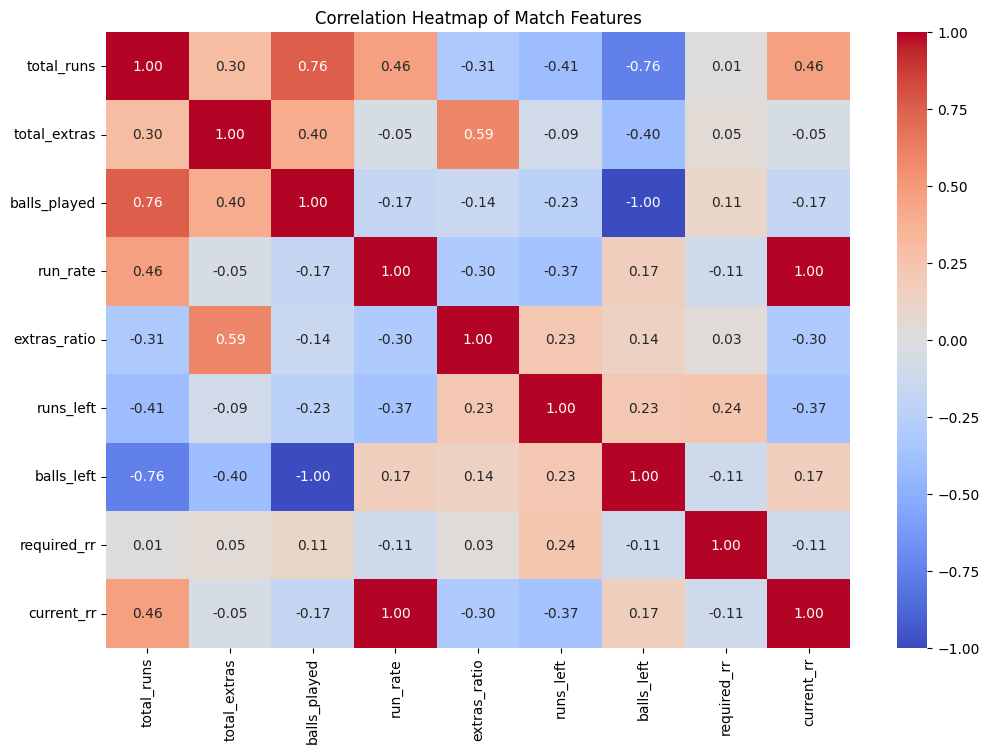

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = [
    'total_runs', 'total_extras', 'balls_played',
    'run_rate', 'extras_ratio',
    'runs_left', 'balls_left',
    'required_rr', 'current_rr'
]

corr = innings_df[numeric_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Match Features")
plt.show()


In [ ]:
innings_df.groupby('inning')['total_runs'].mean()


,total_runs
inning,
2nd innings,202.690834


In [ ]:
innings_df['toss_win_match'].mean() * 100


np.float64(48.87140902872777)

In [ ]:
innings_df.groupby('bat_first')['toss_win_match'].mean()
#TOSS BAT FIRST WIN PERCENTAGE

,toss_win_match
bat_first,
0,0.488714


In [ ]:
innings_df.groupby('venue')['total_runs'].mean().sort_values(ascending=False).head(10)


,total_runs
venue,
Barsapara Cricket Stadium,326.000000
"Grange Cricket Club Ground, Raeburn Place, Edinburgh",307.000000
"Barsapara Cricket Stadium, Guwahati",306.000000
"Sardar Patel (Gujarat) Stadium, Motera",302.500000
M.Chinnaswamy Stadium,301.000000
Vidarbha Cricket Association Ground,299.000000
"National Cricket Stadium, Grenada",294.000000
The Cooper Associates County Ground,294.000000
Saurashtra Cricket Association Stadium,290.666667


In [ ]:
innings_df.groupby('inning')['run_rate'].mean()
innings_df[['extras_ratio','total_runs']].corr()


,extras_ratio,total_runs
extras_ratio,1.000000,-0.308844
total_runs,-0.308844,1.000000


In [ ]:
innings_df.groupby(pd.cut(innings_df['required_rr'], bins=[0,4,6,8,10,20]))['toss_win_match'].mean()


/tmp/ipython-input-3824951759.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  innings_df.groupby(pd.cut(innings_df['required_rr'], bins=[0,4,6,8,10,20]))['toss_win_match'].mean()


,toss_win_match
required_rr,
"(0, 4]",0.487013
"(4, 6]",0.378378
"(6, 8]",0.509091
"(8, 10]",0.503876
"(10, 20]",0.472376


In [ ]:
innings_df.groupby(pd.cut(innings_df['balls_left'], bins=[0,60,120,180,300]))['toss_win_match'].mean()


/tmp/ipython-input-3021414427.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  innings_df.groupby(pd.cut(innings_df['balls_left'], bins=[0,60,120,180,300]))['toss_win_match'].mean()


,toss_win_match
balls_left,
"(0, 60]",0.480499
"(60, 120]",0.520339
"(120, 180]",0.490196
"(180, 300]",0.453901


In [ ]:
innings_df.groupby(pd.cut(innings_df['first_innings_total'], bins=[150,200,250,300,350]))['toss_win_match'].mean()


/tmp/ipython-input-756525063.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  innings_df.groupby(pd.cut(innings_df['first_innings_total'], bins=[150,200,250,300,350]))['toss_win_match'].mean()


,toss_win_match
first_innings_total,
"(150, 200]",0.479212
"(200, 250]",0.478043
"(250, 300]",0.491337
"(300, 350]",0.488263


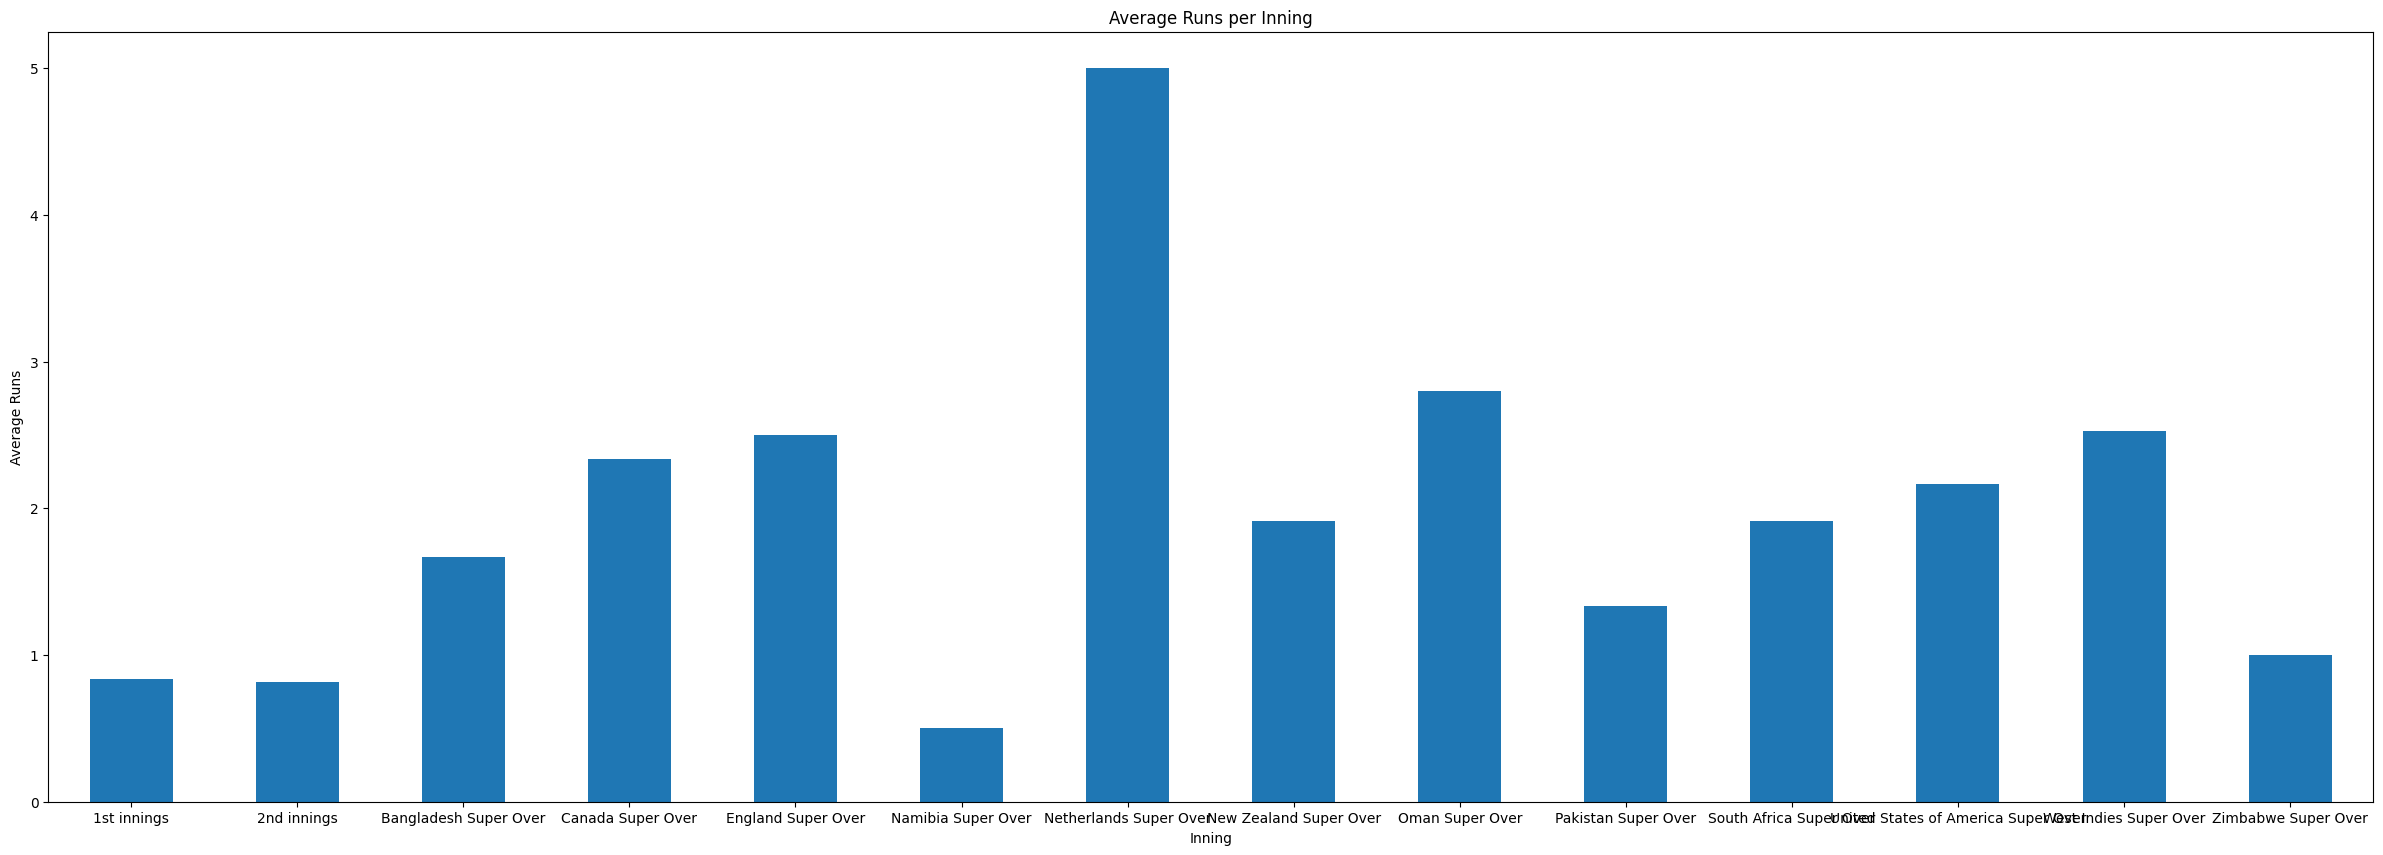

In [ ]:
plt.figure(figsize=(30,10))
df_full.groupby('inning')['runs'].mean().plot(kind='bar')
plt.title("Average Runs per Inning")
plt.ylabel("Average Runs")
plt.xlabel("Inning")
plt.xticks(rotation=0)
plt.show()


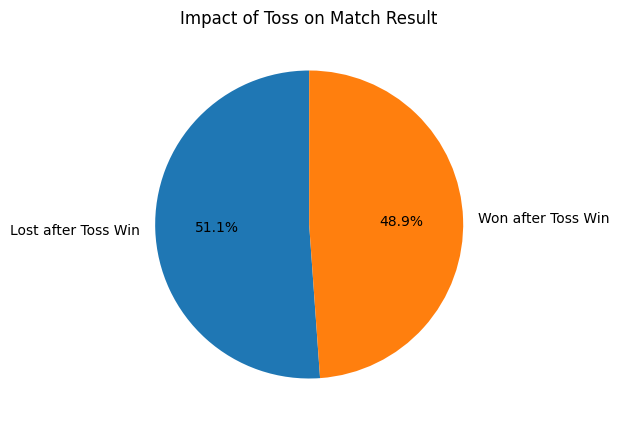

In [ ]:
toss_win_pct = innings_df['toss_win_match'].value_counts(normalize=True) * 100

plt.figure(figsize=(5,5))
plt.pie(toss_win_pct, labels=['Lost after Toss Win','Won after Toss Win'],
        autopct='%1.1f%%', startangle=90)
plt.title("Impact of Toss on Match Result")
plt.show()


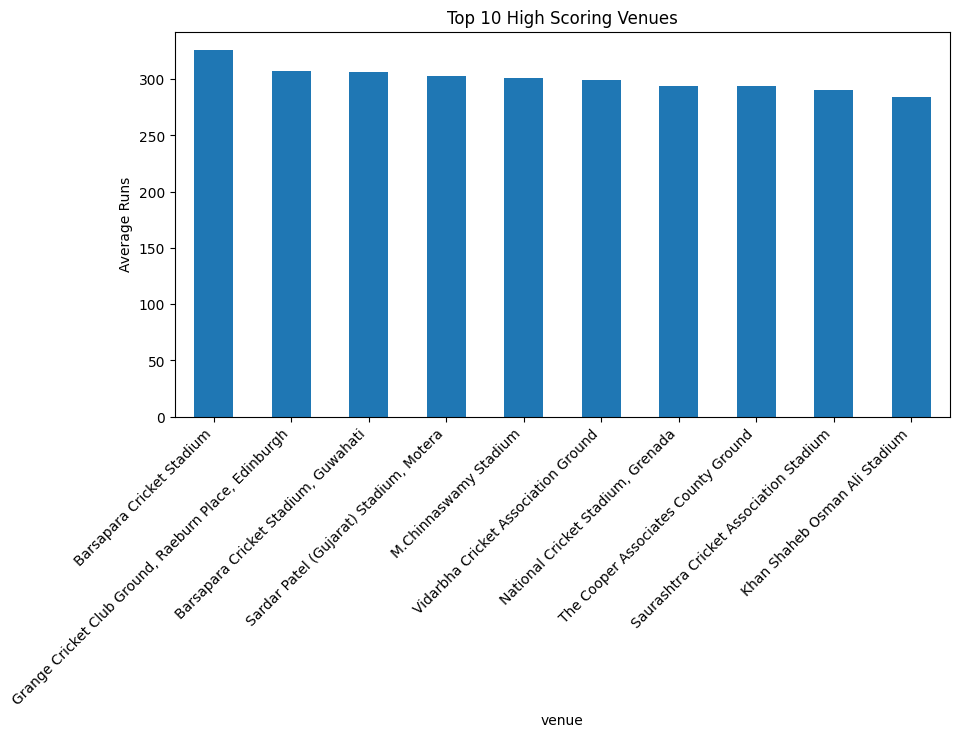

In [ ]:
top_venues = innings_df.groupby('venue')['total_runs'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_venues.plot(kind='bar')
plt.title("Top 10 High Scoring Venues")
plt.ylabel("Average Runs")
plt.xticks(rotation=45, ha='right')
plt.show()


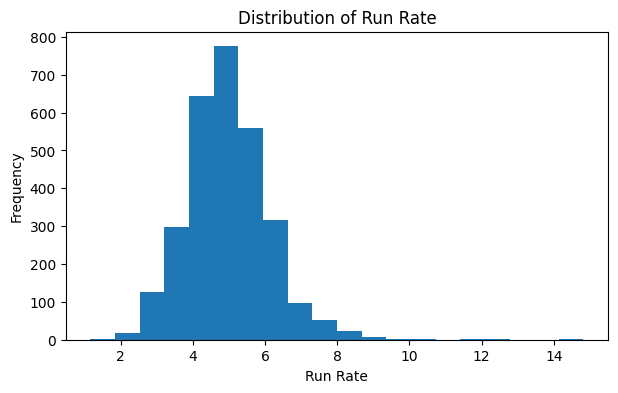

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(innings_df['run_rate'], bins=20)
plt.title("Distribution of Run Rate")
plt.xlabel("Run Rate")
plt.ylabel("Frequency")
plt.show()


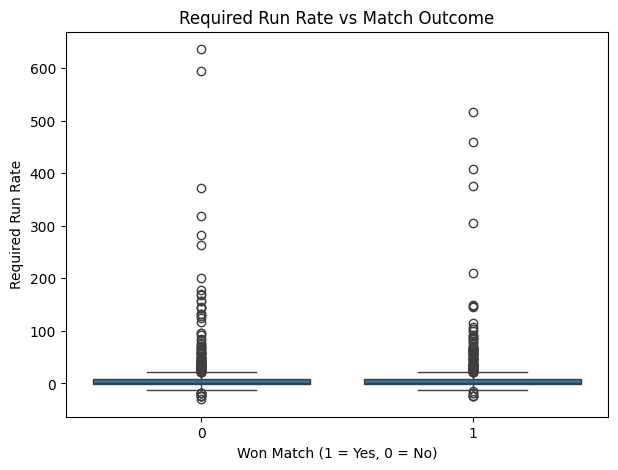

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x='toss_win_match', y='required_rr', data=innings_df)
plt.title("Required Run Rate vs Match Outcome")
plt.xlabel("Won Match (1 = Yes, 0 = No)")
plt.ylabel("Required Run Rate")
plt.show()


/tmp/ipython-input-942311758.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  win_by_balls = innings_df.groupby(balls_bins)['toss_win_match'].mean()


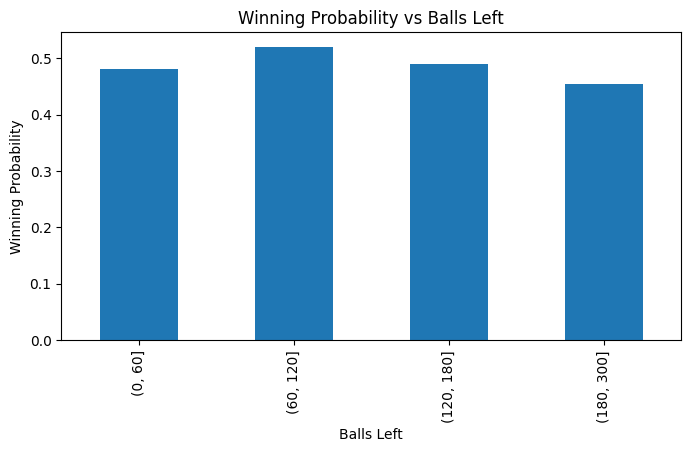

In [ ]:
balls_bins = pd.cut(innings_df['balls_left'], bins=[0,60,120,180,300])
win_by_balls = innings_df.groupby(balls_bins)['toss_win_match'].mean()

plt.figure(figsize=(8,4))
win_by_balls.plot(kind='bar')
plt.title("Winning Probability vs Balls Left")
plt.ylabel("Winning Probability")
plt.xlabel("Balls Left")
plt.show()


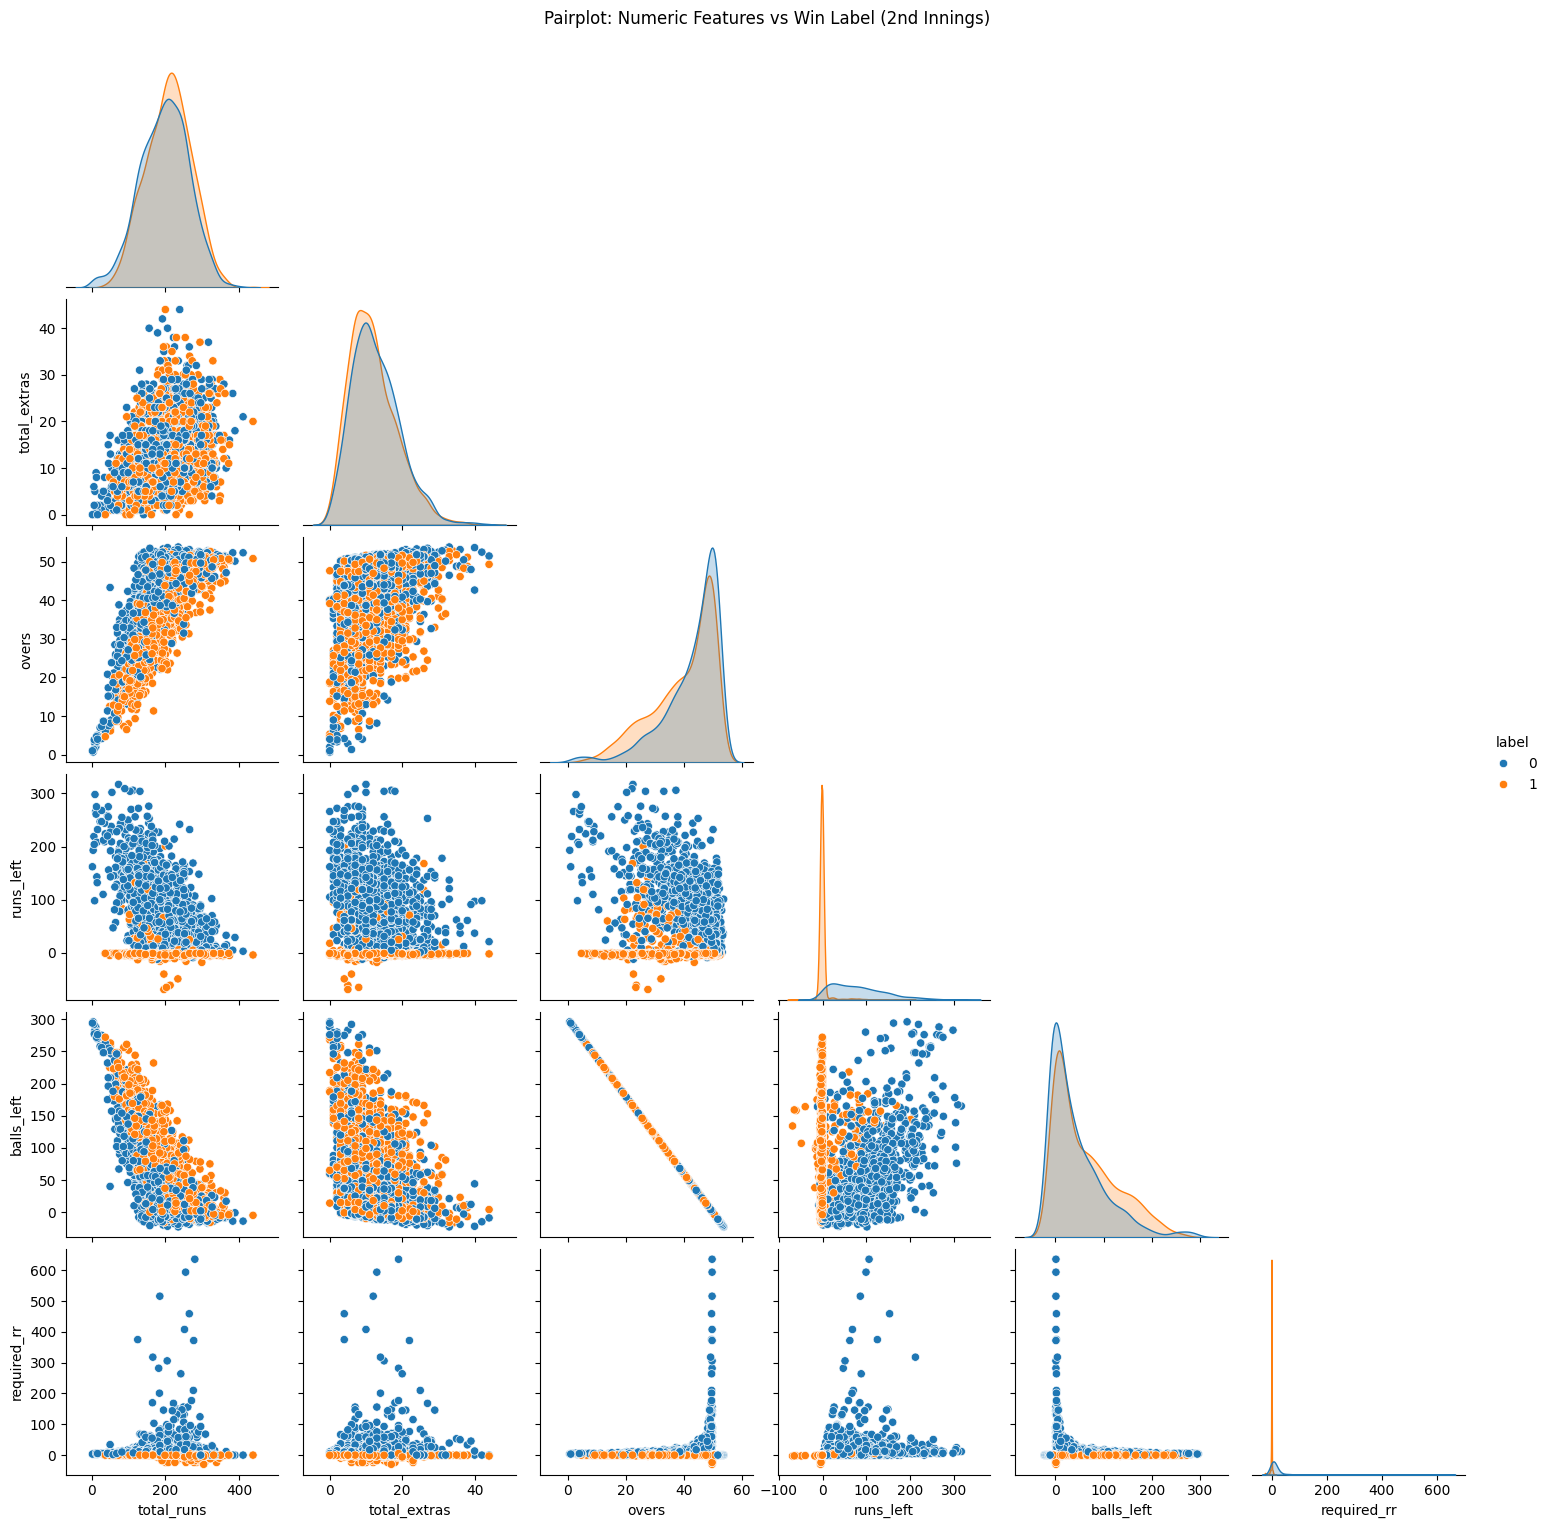

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter only 2nd innings
second_innings = innings_df[innings_df['inning'] == '2nd innings'].copy()

# Create win label: 1 if batting team won, else 0
second_innings['label'] = (second_innings['batting_team'] == second_innings['winner']).astype(int)
numeric_features = ['total_runs', 'total_extras', 'overs', 'runs_left', 'balls_left', 'required_rr']
sns.pairplot(second_innings[numeric_features + ['label']], hue='label', corner=True)
plt.suptitle("Pairplot: Numeric Features vs Win Label (2nd Innings)", y=1.02)
plt.show()


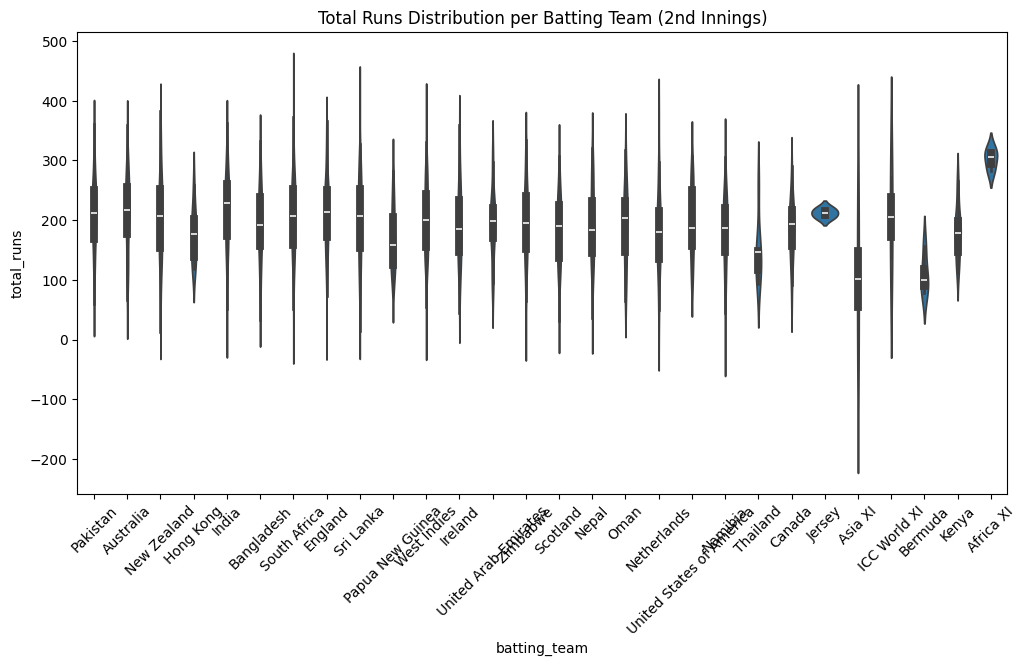

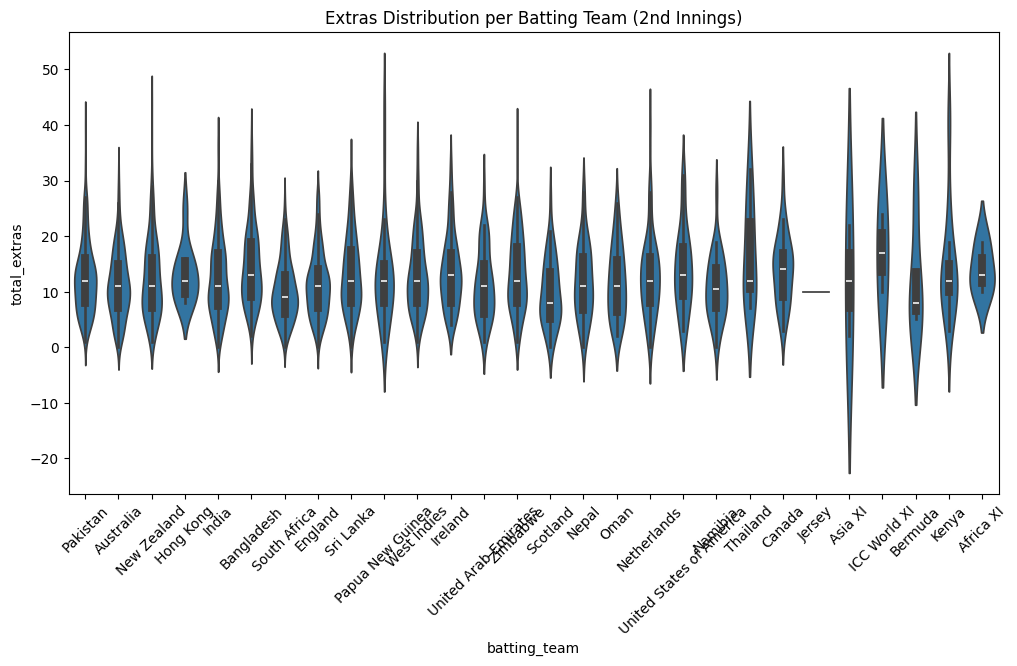

In [ ]:
# Filter 2nd innings only
innings_df_team = innings_df[innings_df['inning'] == '2nd innings']

# Total runs distribution per team
plt.figure(figsize=(12,6))
sns.violinplot(x='batting_team', y='total_runs', data=innings_df_team)
plt.title("Total Runs Distribution per Batting Team (2nd Innings)")
plt.xticks(rotation=45)
plt.show()

# Extras distribution per team
plt.figure(figsize=(12,6))
sns.violinplot(x='batting_team', y='total_extras', data=innings_df_team)
plt.title("Extras Distribution per Batting Team (2nd Innings)")
plt.xticks(rotation=45)
plt.show()


In [ ]:
innings_df['label'] = (innings_df['batting_team'] ==innings_df['winner']).astype(int)


In [ ]:
df_innings_2nd =innings_df[innings_df['inning'] == '2nd innings']

team_stats = df_innings_2nd.groupby('batting_team').agg(
    avg_runs=('total_runs','mean'),
    avg_extras=('total_extras','mean'),
    avg_overs=('overs','mean'),
    wins=('label','sum'),
    total_matches=('label','count')
).reset_index()

team_stats['win_pct'] = (team_stats['wins'] / team_stats['total_matches'] * 100).round(2)
team_stats


,batting_team,avg_runs,avg_extras,avg_overs,wins,total_matches,win_pct
0,Africa XI,302.333333,14.000000,50.222222,0,3,0.00
1,Asia XI,102.000000,12.000000,27.250000,0,2,0.00
2,Australia,211.216000,11.304000,39.792000,176,250,70.40
3,Bangladesh,193.016760,14.525140,41.882682,79,179,44.13
4,Bermuda,108.500000,12.000000,26.083333,1,4,25.00
5,Canada,184.303030,13.939394,43.282828,10,33,30.30
6,England,211.656934,11.339416,40.718978,161,274,58.76
7,Hong Kong,174.900000,13.100000,40.950000,2,10,20.00
8,ICC World XI,205.000000,17.000000,38.166667,0,2,0.00
9,India,219.253918,12.460815,42.237722,205,319,64.26


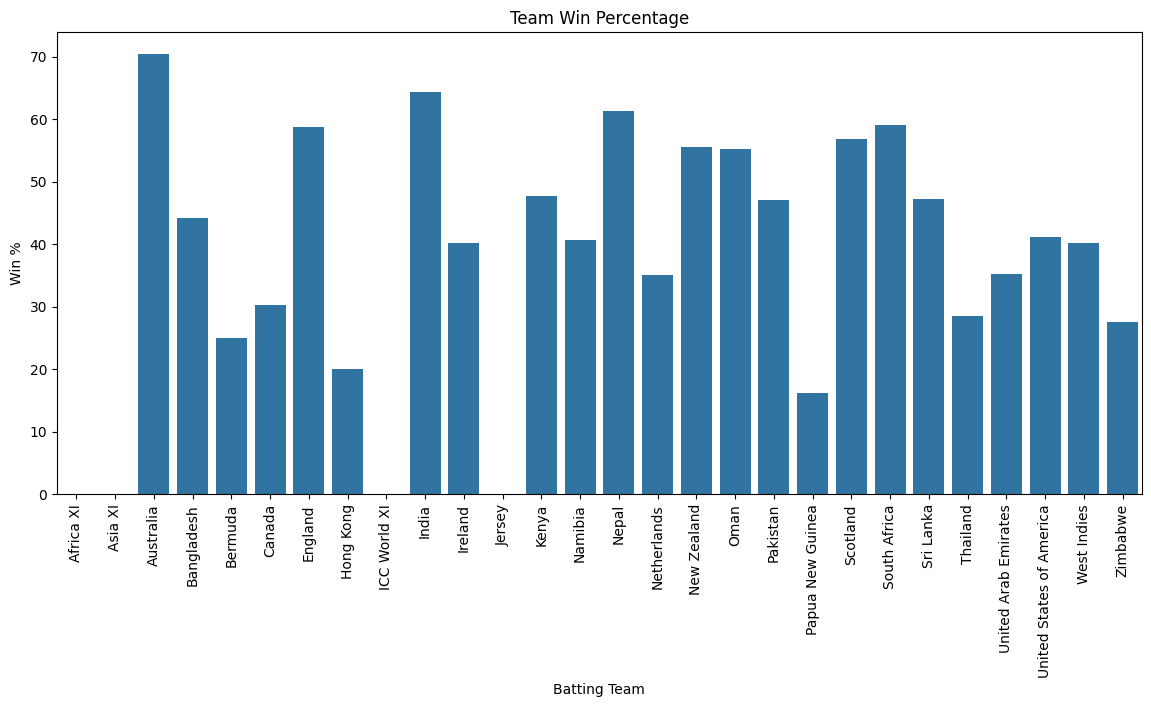

In [ ]:
plt.figure(figsize=(14,6))
sns.barplot(x='batting_team', y='win_pct', data=team_stats)
plt.xticks(rotation=90)
plt.title("Team Win Percentage")
plt.ylabel("Win %")
plt.xlabel("Batting Team")
plt.show()


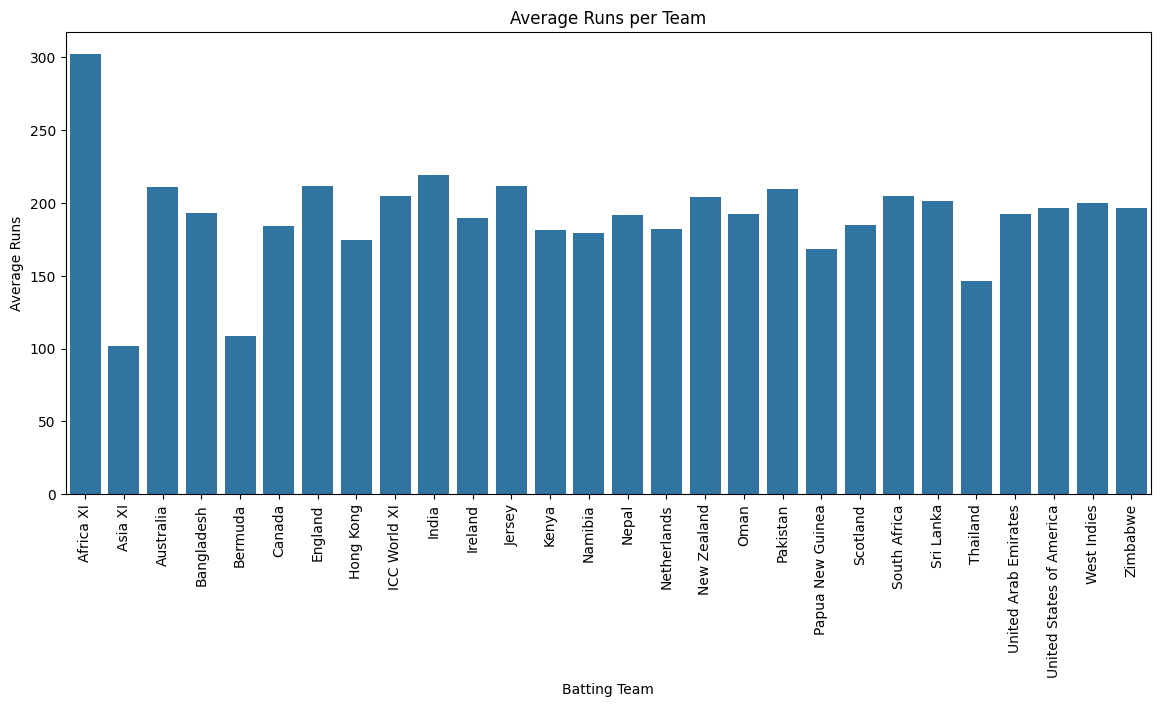

In [ ]:
plt.figure(figsize=(14,6))
sns.barplot(x='batting_team', y='avg_runs', data=team_stats)
plt.xticks(rotation=90)
plt.title("Average Runs per Team")
plt.ylabel("Average Runs")
plt.xlabel("Batting Team")
plt.show()


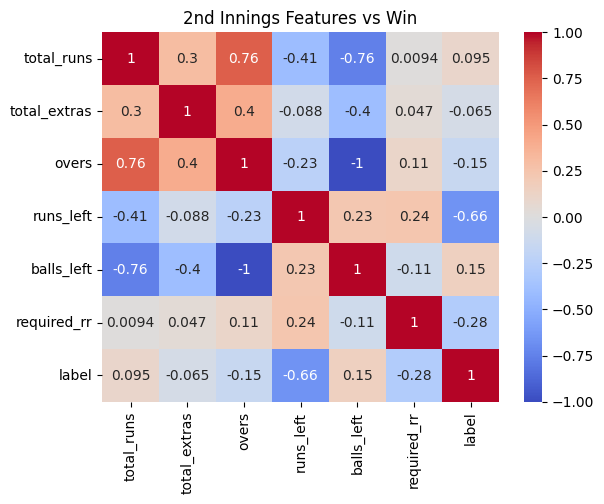

In [ ]:
sns.heatmap(second_innings[numeric_features + ['label']].corr(), annot=True, cmap='coolwarm')
plt.title("2nd Innings Features vs Win")
plt.show()


In [ ]:
second_innings.to_csv('/content/odi_2nd_innings_clean.csv', index=False)


In [ ]:
# Function to replace rare categories with 'Other'
def replace_rare_categories(df, col, min_count=5):
    counts = df[col].value_counts()
    rare = counts[counts < min_count].index
    df[col] = df[col].replace(rare, 'Other')
    return df

for cat_col in ['batting_team', 'bowling_team', 'venue', 'toss_winner', 'toss_decision']:
    innings_df = replace_rare_categories(innings_df, cat_col, min_count=5)


In [ ]:
X_categorical = pd.get_dummies(
    innings_df[['batting_team', 'bowling_team', 'venue', 'toss_winner', 'toss_decision']],
    drop_first=True
)


In [ ]:
numeric_features = [
    'first_innings_total', 'total_runs', 'runs_left', 'balls_left', 'required_rr', 'current_rr'
]


In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

X_numeric = innings_df[numeric_features]
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric)

X_final = np.hstack([X_numeric_scaled, X_categorical.values])
y = innings_df['label'].values


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt


In [ ]:
# =========================
# Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# =========================
# Random Forest Base
# =========================
rf_model = RandomForestClassifier(
    random_state=42,
    bootstrap=True,
    max_samples=0.8,   # each tree sees 80% of data
    n_jobs=-1,
    class_weight='balanced'
)

# =========================
# Hyperparameter Grid
# =========================
param_grid = {
    'n_estimators': [200, 300],         # slightly fewer trees
    'max_depth': [6, 8],                # smaller trees
    'min_samples_split': [8, 10],       # require more samples to split
    'min_samples_leaf': [5, 6],         # larger leaves → smoother predictions
    'max_features': ['sqrt']  ,          # keep as default
}




In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid,
    n_iter=16,           # exactly all combinations
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
    random_state=42

)

random_search.fit(X_train, y_train)


Fitting 3 folds for each of 16 candidates, totalling 48 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    max_samples=0.8, n_jobs=-1,
                                                    random_state=42),
                   n_iter=16, n_jobs=-1,
                   param_distributions={'max_depth': [6, 8],
                                        'max_features': ['sqrt'],
                                        'min_samples_leaf': [5, 6],
                                        'min_samples_split': [8, 10],
                                        'n_estimators': [200, 300]},
                   random_state=42, scoring='accuracy', verbose=2)

Training Accuracy: 0.9653698161607525
Test Accuracy: 0.9658119658119658
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       287
           1       1.00      0.94      0.97       298

    accuracy                           0.97       585
   macro avg       0.97      0.97      0.97       585
weighted avg       0.97      0.97      0.97       585



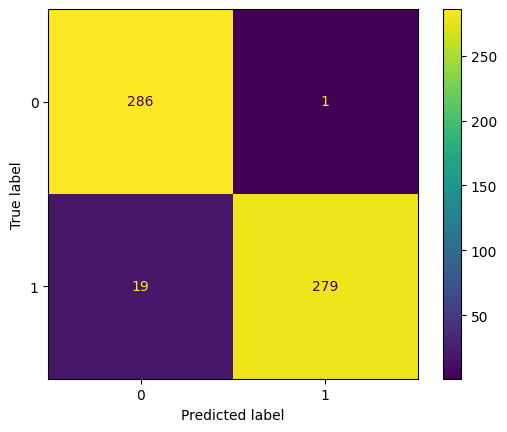

In [ ]:
best_rf = random_search.best_estimator_

y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(y_test, y_test_pred))

ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test)
plt.show()


In [ ]:
from sklearn.metrics import log_loss

# Predict probabilities instead of class labels
y_test_proba = best_rf.predict_proba(X_test)

# Compute log loss
loss = log_loss(y_test, y_test_proba)
print("Log Loss:", loss)


Log Loss: 0.24399598429192623


In [ ]:
y_train_proba = best_rf.predict_proba(X_train)
train_loss = log_loss(y_train, y_train_proba)
print("Training Log Loss:", train_loss)


Training Log Loss: 0.2369127496670643


Test AUC: 0.9914528915183687


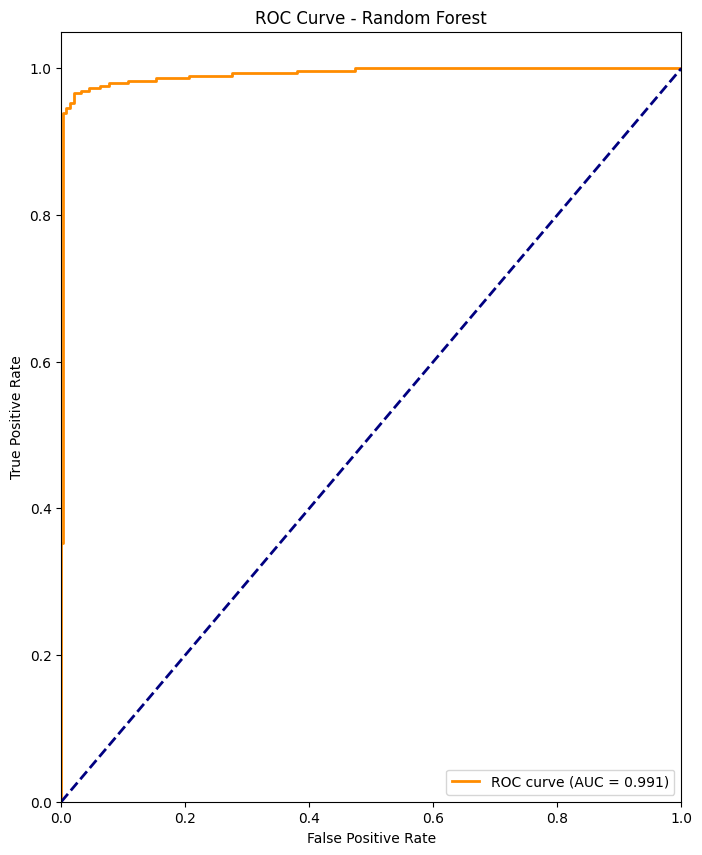

In [ ]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# Predicted probabilities for class 1
y_test_proba = best_rf.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

# Compute AUC
roc_auc = auc(fpr, tpr)
print("Test AUC:", roc_auc)

# Plot ROC Curve
plt.figure(figsize=(8,10))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.3f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.show()


Average Precision (AP): 0.9916697284081271


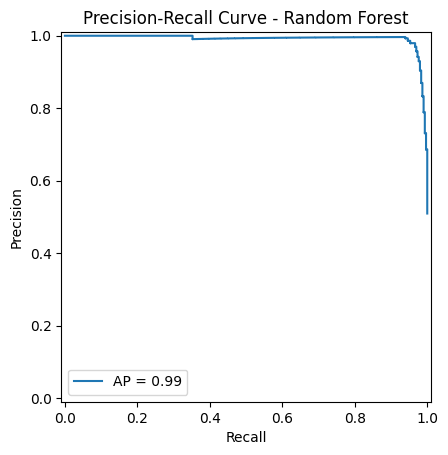

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Predicted probabilities for positive class (Class 1)
y_scores = best_rf.predict_proba(X_test)[:, 1]

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Compute Average Precision (AP)
average_precision = average_precision_score(y_test, y_scores)
print("Average Precision (AP):", average_precision)

# Plot Precision-Recall curve correctly
disp = PrecisionRecallDisplay(precision=precision, recall=recall, average_precision=average_precision)
disp.plot()  # This automatically creates and displays the figure
plt.title('Precision-Recall Curve - Random Forest')
plt.show()


               Feature  Importance
2            runs_left    0.344739
4          required_rr    0.310103
0  first_innings_total    0.124723
5           current_rr    0.068749
3           balls_left    0.035432
6              batting    0.030495
7              bowling    0.029721
1           total_runs    0.026490
9                venue    0.016315
8                 toss    0.013232


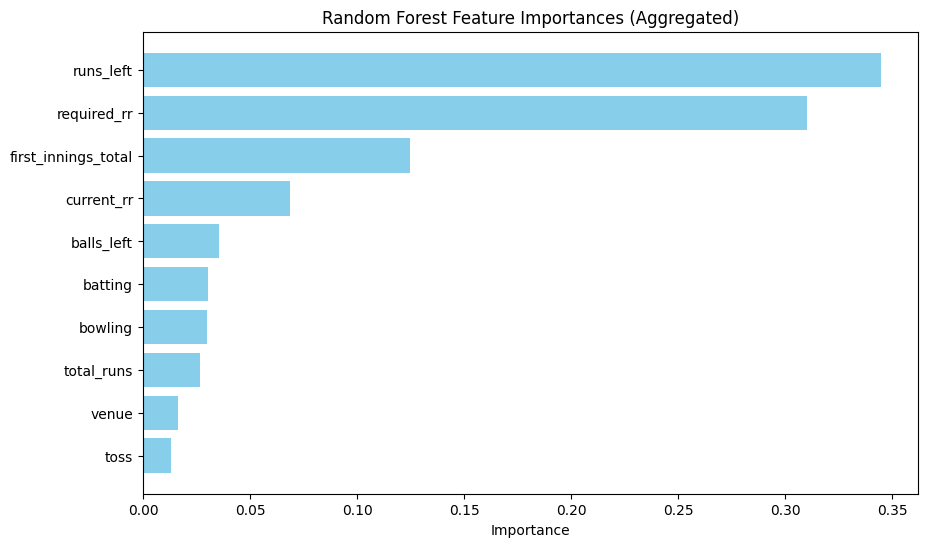

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Numeric features
numeric_features = list(X_numeric.columns)
numeric_importances = best_rf.feature_importances_[:len(numeric_features)]

# Categorical features
categorical_importances = best_rf.feature_importances_[len(numeric_features):]
categorical_feature_names = X_categorical.columns

# Aggregate categorical importances by original column prefix
cat_importance_df = pd.DataFrame({
    'Feature': categorical_feature_names,
    'Importance': categorical_importances
})

cat_importance_agg = cat_importance_df.groupby(lambda x: categorical_feature_names[x].split('_')[0])['Importance'].sum()

# Combine numeric + aggregated categorical
final_feat_importance = pd.DataFrame({
    'Feature': numeric_features + list(cat_importance_agg.index),
    'Importance': np.concatenate([numeric_importances, cat_importance_agg.values])
}).sort_values(by='Importance', ascending=False)

print(final_feat_importance)

# Plot top 15
plt.figure(figsize=(10,6))
plt.barh(final_feat_importance['Feature'][:15], final_feat_importance['Importance'][:15], color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Random Forest Feature Importances (Aggregated)')
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 4 candidates, totalling 12 fits
Training Accuracy: 0.9491235570756734
Test Accuracy: 0.9025641025641026

Test Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       287
           1       0.89      0.92      0.91       298

    accuracy                           0.90       585
   macro avg       0.90      0.90      0.90       585
weighted avg       0.90      0.90      0.90       585

Training Log Loss: 0.1586723995155765
Test Log Loss: 0.29730488244305747


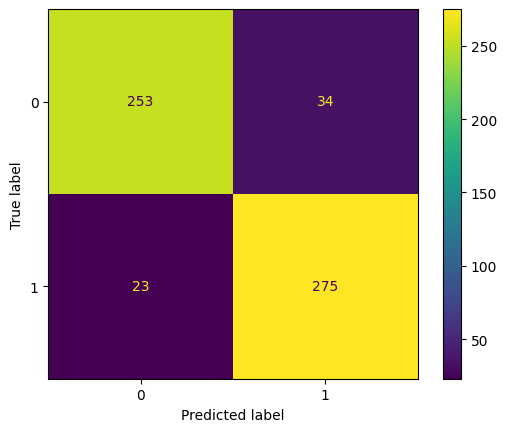

In [ ]:
# =========================
# Imports
# =========================
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, log_loss, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# =========================
# Train-test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# Feature scaling (important for Logistic Regression)
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# Logistic Regression Base Model
# =========================
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000,         # ensure convergence
    class_weight='balanced'  # handle class imbalance
)

# =========================
# Hyperparameter Grid
# =========================
param_grid = {
    'C': [0.01, 0.05, 0.1, 0.5],       # inverse of regularization strength
    'penalty': ['l2'],                   # regularization type
    'solver': ['lbfgs']                  # solver compatible with l2
}

# =========================
# Stratified 3-Fold CV & Randomized Search
# =========================
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_grid,
    n_iter=5,          # small grid, few iterations
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# =========================
# Fit Logistic Regression
# =========================
random_search.fit(X_train_scaled, y_train)

# =========================
# Best model
# =========================
best_logreg = random_search.best_estimator_

# =========================
# Predictions
# =========================
y_train_pred = best_logreg.predict(X_train_scaled)
y_test_pred = best_logreg.predict(X_test_scaled)

y_train_proba = best_logreg.predict_proba(X_train_scaled)
y_test_proba = best_logreg.predict_proba(X_test_scaled)

# =========================
# Evaluation
# =========================
# Evaluation
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))

print("Training Log Loss:", log_loss(y_train, y_train_proba))
print("Test Log Loss:", log_loss(y_test, y_test_proba))

ConfusionMatrixDisplay.from_estimator(best_logreg, X_test_scaled, y_test)
plt.show()



In [ ]:
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
TN, FP, FN, TP = cm.ravel()

# Calculate metrics
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print("Sensitivity (Recall for Class 1):", sensitivity)
print("Specificity (Recall for Class 0):", specificity)


Sensitivity (Recall for Class 1): 0.9228187919463087
Specificity (Recall for Class 0): 0.8815331010452961


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, log_loss


In [ ]:
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=1   # classes are nearly balanced
)



In [ ]:
param_grid = {
    'n_estimators': [100, 150, 200],       # fewer trees → less overfit
    'max_depth': [3, 4],                   # shallower trees generalize better
    'learning_rate': [0.05, 0.07, 0.1],   # slightly slower learning, more stable
    'subsample': [0.7, 0.8, 0.9],         # use part of rows per tree → randomness
    'colsample_bytree': [0.7, 0.8, 0.9],  # use part of features per tree → randomness
    'min_child_weight': [4, 5, 6],         # prevent splits on very small samples
    'gamma': [0.1, 0.2, 0.3],              # min loss reduction to split → reduces overfitting
    'reg_alpha': [0, 0.1, 0.5],            # L1 regularization
    'reg_lambda': [1, 1.5, 2]              # L2 regularization
}


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=25,
    scoring='accuracy',
    cv=skf,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search_xgb.fit(X_train, y_train)


Fitting 5 folds for each of 25 candidates, totalling 125 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:50:37] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None...
                                           n_estimators=None, n_jobs=-1,
                                           num_parallel_tree=None, ...),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9],
                                        'gamma': [0.1, 0.2, 0.3],
                                        'learning_rate': [0.05, 0.07, 0.1],
                                        'max_depth': [3, 4],
                                        'min_child_weight': [4, 5, 6],
                                        'n_estimators': [100, 150, 200],
                                        'reg_alpha': [0, 0.1, 0.5],
                                        'reg_lambda': [1, 1.5, 2],
                                        'subsample': [0.7, 0.8, 0.9]},
                   random_state=42, scoring='accuracy', verbose=2)

In [ ]:
best_xgb = random_search_xgb.best_estimator_
print("Best Parameters:", random_search_xgb.best_params_)


Best Parameters: {'subsample': 0.9, 'reg_lambda': 1.5, 'reg_alpha': 0.5, 'n_estimators': 150, 'min_child_weight': 6, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}


In [ ]:
# Predictions
y_train_pred = best_xgb.predict(X_train)
y_test_pred = best_xgb.predict(X_test)

y_train_proba = best_xgb.predict_proba(X_train)
y_test_proba = best_xgb.predict_proba(X_test)

# Accuracy
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

# Classification Report
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))

# Log Loss
print("Training Log Loss:", log_loss(y_train, y_train_proba))
print("Test Log Loss:", log_loss(y_test, y_test_proba))


Training Accuracy: 0.9841812740487388
Test Accuracy: 0.9777777777777777

Test Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       287
           1       0.99      0.97      0.98       298

    accuracy                           0.98       585
   macro avg       0.98      0.98      0.98       585
weighted avg       0.98      0.98      0.98       585

Training Log Loss: 0.046693460582183606
Test Log Loss: 0.07374745653637088


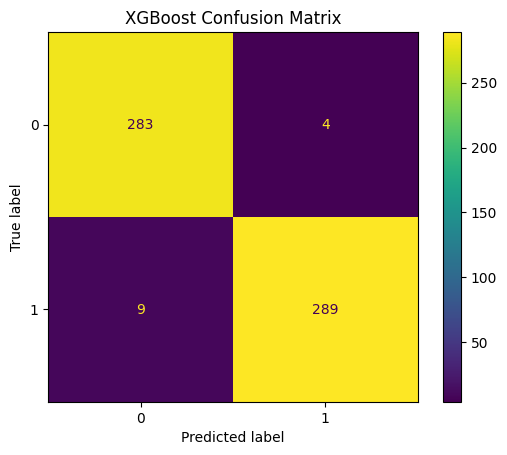

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(best_xgb, X_test, y_test)
plt.title("XGBoost Confusion Matrix")
plt.show()


XGBoost Average Precision (AP): 0.9941532836838918


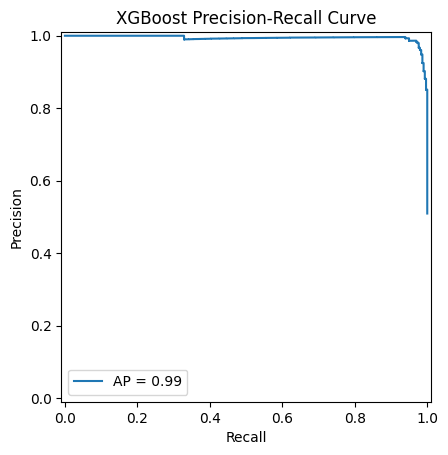

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay

# Predicted probabilities for class 1
y_scores = best_xgb.predict_proba(X_test)[:, 1]

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Compute Average Precision (AP)
average_precision = average_precision_score(y_test, y_scores)
print("XGBoost Average Precision (AP):", average_precision)

# Plot Precision-Recall curve
disp = PrecisionRecallDisplay(precision=precision, recall=recall, average_precision=average_precision)
disp.plot()
plt.title('XGBoost Precision-Recall Curve')
plt.show()


XGBoost Test AUC: 0.9952178284965975


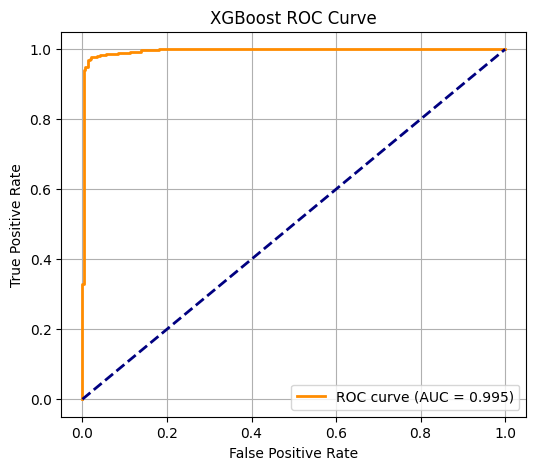

In [ ]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt

# Predicted probabilities for class 1
y_scores = best_xgb.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Compute AUC
roc_auc = auc(fpr, tpr)
print("XGBoost Test AUC:", roc_auc)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


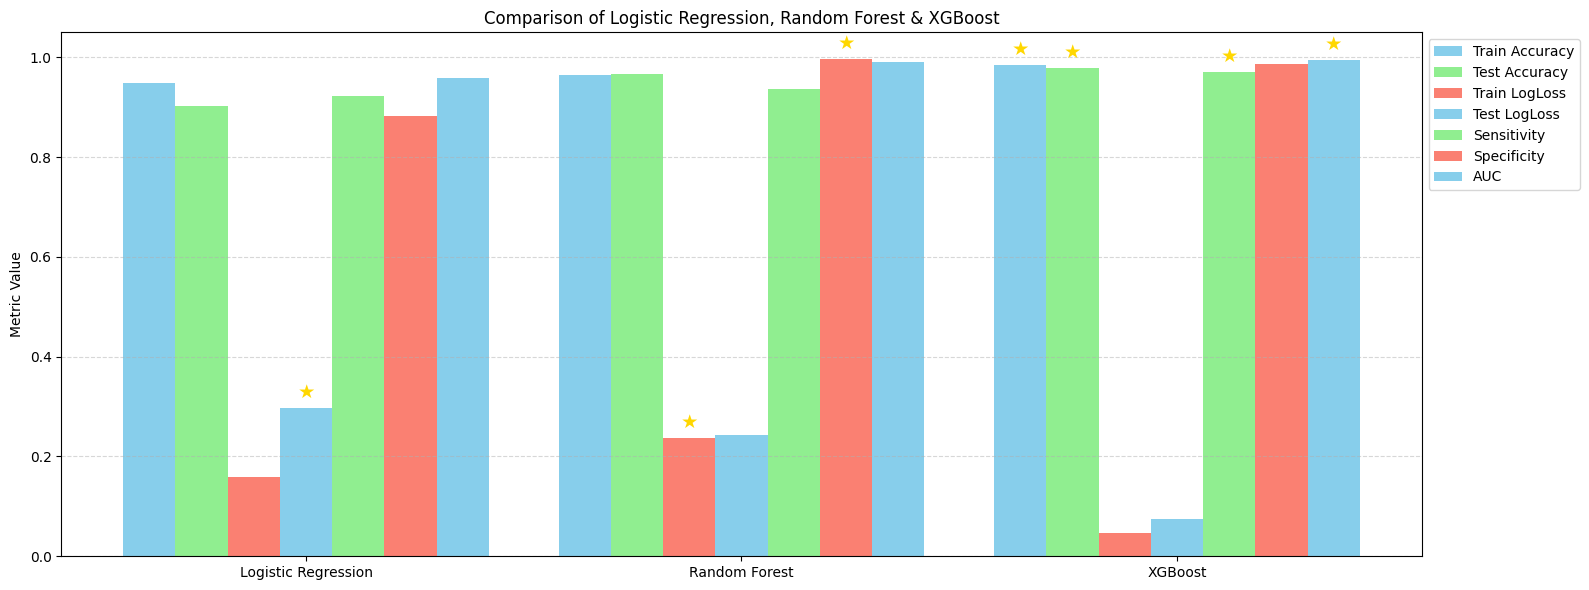

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, roc_auc_score

# 1️⃣ Prepare models and names
models = {
    'Logistic Regression': best_logreg,
    'Random Forest': best_rf,
    'XGBoost': best_xgb
}

# 2️⃣ Data for each model
X_trains = {
    'Logistic Regression': X_train_scaled,
    'Random Forest': X_train,
    'XGBoost': X_train
}

X_tests = {
    'Logistic Regression': X_test_scaled,
    'Random Forest': X_test,
    'XGBoost': X_test
}

y_trains = y_train
y_tests = y_test

# 3️⃣ Collect metrics
metrics = {
    'Train Accuracy': [],
    'Test Accuracy': [],
    'Train LogLoss': [],
    'Test LogLoss': [],
    'Sensitivity': [],
    'Specificity': [],
    'AUC': []
}

for name, model in models.items():
    y_train_pred = model.predict(X_trains[name])
    y_test_pred = model.predict(X_tests[name])

    if hasattr(model, "predict_proba"):
        y_train_proba = model.predict_proba(X_trains[name])
        y_test_proba = model.predict_proba(X_tests[name])
        y_test_proba_class1 = y_test_proba[:,1]
    else:
        y_train_proba = model.predict_proba(X_trains[name])
        y_test_proba = model.predict_proba(X_tests[name])
        y_test_proba_class1 = y_test_proba[:,1]

    metrics['Train Accuracy'].append(accuracy_score(y_trains, y_train_pred))
    metrics['Test Accuracy'].append(accuracy_score(y_tests, y_test_pred))

    metrics['Train LogLoss'].append(log_loss(y_trains, y_train_proba))
    metrics['Test LogLoss'].append(log_loss(y_tests, y_test_proba))

    tn, fp, fn, tp = confusion_matrix(y_tests, y_test_pred).ravel()
    metrics['Sensitivity'].append(tp / (tp + fn))
    metrics['Specificity'].append(tn / (tn + fp))

    metrics['AUC'].append(roc_auc_score(y_tests, y_test_proba_class1))

# 4️⃣ Plotting all metrics
metric_names = list(metrics.keys())
num_metrics = len(metric_names)
x = np.arange(len(models))
width = 0.12

plt.figure(figsize=(16,6))
colors = ['skyblue', 'lightgreen', 'salmon']

for i, metric in enumerate(metric_names):
    plt.bar(x + width*i - width*3, metrics[metric], width=width, color=colors[i%3], label=metric)

plt.xticks(x, models.keys())
plt.ylim(0, 1.05)
plt.title("Comparison of Logistic Regression, Random Forest & XGBoost")
plt.ylabel("Metric Value")
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Highlight the best metric values with a star
for i, metric in enumerate(metric_names):
    best_idx = np.argmax(metrics[metric])
    plt.text(best_idx + width*i - width*3, metrics[metric][best_idx]+0.02, '★', color='gold', fontsize=14, ha='center')

plt.tight_layout()
plt.show()


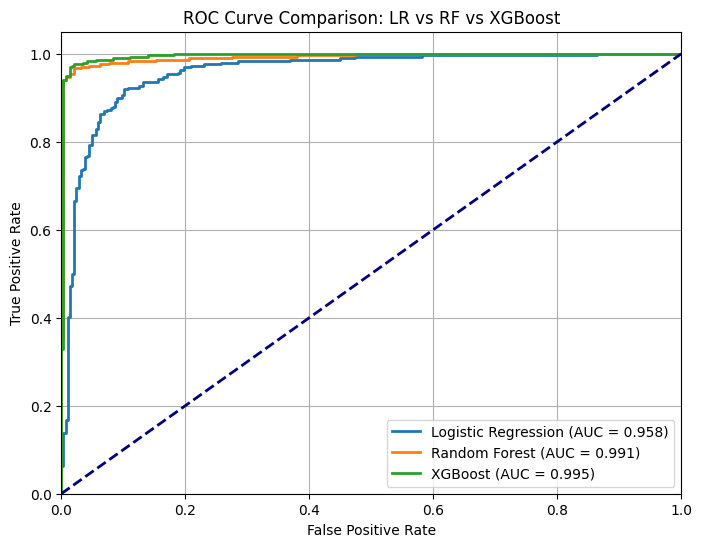

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Dictionary of models and corresponding train/test data
models = {
    'Logistic Regression': (best_logreg, X_test_scaled),
    'Random Forest': (best_rf, X_test),
    'XGBoost': (best_xgb, X_test)
}

plt.figure(figsize=(8,6))

for name, (model, X_t) in models.items():
    # Predict probabilities for class 1
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_t)[:, 1]
    else:
        # fallback if no predict_proba
        y_score = model.decision_function(X_t)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Plot diagonal line for random classifier
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: LR vs RF vs XGBoost')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
